In [86]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from typing import TypedDict,Annotated,List,Any
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,AIMessage,BaseMessage,SystemMessage
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command,interrupt
from sentence_transformers import SentenceTransformer
import numpy as np
import uuid
from chromadb.config import Settings
import chromadb
import os
load_dotenv()

True

In [15]:
# Sample documents
documents = [
    "This is a list which containig sample documents.",
    "Keywords are important for keyword-based search.",
    "Document analysis involves extracting keywords.",
    "Keyword-based search relies on sparse embeddings."
]
     
query="keyword-based search"

In [16]:
import re
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    return text


preprocess_documents=[preprocess_text(doc) for doc in documents]
     

preprocess_documents
     

print("Preprocessed Documents:")
for doc in preprocess_documents:
    print(doc)
     

print("Preprocessed Query:")
print(query)
     

preprocessed_query = preprocess_text(query)
     

preprocessed_query

Preprocessed Documents:
this is a list which containig sample documents
keywords are important for keywordbased search
document analysis involves extracting keywords
keywordbased search relies on sparse embeddings
Preprocessed Query:
keyword-based search


'keywordbased search'

In [17]:
vector=TfidfVectorizer()
x=vector.fit_transform(preprocess_documents)
array=x.toarray()

In [18]:
array

array([[0.        , 0.        , 0.37796447, 0.        , 0.37796447,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.37796447, 0.        , 0.        , 0.37796447, 0.        ,
        0.        , 0.37796447, 0.        , 0.        , 0.37796447,
        0.37796447],
       [0.        , 0.4533864 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.4533864 , 0.4533864 , 0.        ,
        0.        , 0.35745504, 0.35745504, 0.        , 0.        ,
        0.        , 0.        , 0.35745504, 0.        , 0.        ,
        0.        ],
       [0.46516193, 0.        , 0.        , 0.46516193, 0.        ,
        0.        , 0.46516193, 0.        , 0.        , 0.46516193,
        0.        , 0.        , 0.36673901, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.43671931, 0.        , 0.        , 0.       

In [19]:
query_embedding=vector.transform([preprocessed_query])
query_embedding

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (1, 21)>

- BM25 is the updated part of TFIDF. TFIDF mainly focuses on keywoad frequency and not on semantic meaning and relationship. Useful when we want to heavily match exact words.
- These generate sparse Matrix
- measures the importance of a word in a document relative to an entire corpus. 
- Corpus refers to the complete data.
-It is a statistical method that is used to evaluate the importance of a word in a document. The TF-IDF approach calculates a score for each word in a document, which reflects its importance in that document.
- TF represents (# of times term comes in a text)/(# of terms in a text)
- IDF represents (# of texts in corpus)/(# of terms texts containing term t in a corpus)
- old method was using this TF x IDF to generate Vectors.
- Now we have vector search and all and here, we use transformers to create vectors from texts which are dense vectors and cosine similarity and all and can be performed on them.

# Keyword based search

In [20]:
similarities=cosine_similarity(x,query_embedding)
similarities

array([[0.        ],
       [0.50551777],
       [0.        ],
       [0.48693426]])

In [21]:
#Ranking
ranked_indices=np.argsort(similarities,axis=0)[::-1].flatten()
ranked_indices

array([1, 3, 2, 0])

In [22]:
np.argsort(similarities,axis=0) #Here sorted indices based on similarities values
ranked_documents = [documents[i] for i in ranked_indices]
ranked_documents

['Keywords are important for keyword-based search.',
 'Keyword-based search relies on sparse embeddings.',
 'Document analysis involves extracting keywords.',
 'This is a list which containig sample documents.']

# Using Vector Embeddings

In [23]:
from sentence_transformers import SentenceTransformer

In [24]:
model=SentenceTransformer("all-MiniLM-L6-v2")
embeddings=model.encode(preprocess_documents)
query_embedding2=model.encode(preprocessed_query).reshape(1,-1)

In [25]:
query_embedding2

array([[-9.34928749e-03, -5.88050708e-02, -2.40736175e-02,
         3.79789397e-02, -2.87498571e-02,  5.33267185e-02,
         7.13340044e-02,  1.72377639e-02, -3.33929881e-02,
         2.41078641e-02,  3.20847183e-02,  1.47228008e-02,
         1.21521279e-01, -3.62913236e-02, -2.07968317e-02,
         8.75071995e-03,  3.46281417e-02,  7.94901997e-02,
        -4.51725759e-02, -2.55422760e-02,  6.80354536e-02,
         4.36825939e-02,  2.13527214e-03, -2.71932054e-02,
        -2.38886811e-02,  3.39270160e-02, -7.04815388e-02,
        -8.11266899e-02,  4.06988561e-02,  3.02442219e-02,
         1.04071070e-02,  5.07700928e-02,  1.10834412e-01,
         1.57443434e-01,  1.31421750e-02, -2.32421532e-02,
        -5.89699410e-02,  4.43411581e-02, -1.04013309e-02,
         3.52705154e-03, -6.07758053e-02,  2.73566064e-03,
        -4.12737206e-02,  2.10162643e-02,  6.19455427e-02,
        -2.87003275e-02, -7.43091479e-02, -3.67941847e-03,
         1.60609223e-02,  5.68192126e-03, -1.07638039e-0

In [26]:
similarities2=cosine_similarity(embeddings,query_embedding2)
similarities2

array([[0.2384148],
       [0.885544 ],
       [0.5083779],
       [0.7863099]], dtype=float32)

In [27]:
#Ranking
ranked_indices2=np.argsort(similarities,axis=0)[::-1].flatten()
ranked_indices2

array([1, 3, 2, 0])

In [28]:
np.argsort(similarities,axis=0) #Here sorted indices based on similarities values
ranked_documents = [documents[i] for i in ranked_indices2]
ranked_documents

['Keywords are important for keyword-based search.',
 'Keyword-based search relies on sparse embeddings.',
 'Document analysis involves extracting keywords.',
 'This is a list which containig sample documents.']

However, cosine_similarity() expects a matrix of shape:

(number_of_samples, number_of_features)
for reshape (1,-1) --> 1 means 1 row
-1 means

"NumPy, you figure out this dimension automatically."

Since there are 384 values total, NumPy calculates

384 values
1 row
→ 384 columns

# Ensemble Search (Keyword + semantic vector search)

In [29]:
from langchain_community.document_loaders import PyMuPDFLoader,DirectoryLoader

In [30]:
dirloader_pdf=DirectoryLoader('../data/pdf/',glob='**/*.pdf',loader_cls=PyMuPDFLoader)
docs_pdf=dirloader_pdf.load()
print(docs_pdf)

[Document(metadata={'producer': 'Acrobat Distiller 10.0.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2025-07-25T11:02:56+05:30', 'source': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'file_path': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'total_pages': 10, 'format': 'PDF 1.5', 'title': 'Microsoft PowerPoint - IT314-Software Engineering-SPM Cont.ppt [Compatibility Mode]', 'author': 'DA-IICT', 'subject': '', 'keywords': '', 'moddate': '2025-07-25T11:02:56+05:30', 'trapped': '', 'modDate': "D:20250725110256+05'30'", 'creationDate': "D:20250725110256+05'30'", 'page': 0}, page_content='7/25/2025\n1\nDA-IICT\nIT 314: Software Engineering\nSoftware Process Models – RUP|XP|TDD\n1\nRUP – Rational Unified Process\n•\nLife Cycle model proposed by Booch, Jacobson, and Rumbaugh\n(“The three Amigos”) derived from the work on UML\n•\nRational Unified Process (RUP) uses Unified Modeling Language\n(UML) as core notation\n•\nDescribed from 3 perspective

In [31]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [32]:
splitter=RecursiveCharacterTextSplitter(chunk_size=200,chunk_overlap=30)

In [33]:
chunks=splitter.split_documents(docs_pdf)
chunks

[Document(metadata={'producer': 'Acrobat Distiller 10.0.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2025-07-25T11:02:56+05:30', 'source': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'file_path': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'total_pages': 10, 'format': 'PDF 1.5', 'title': 'Microsoft PowerPoint - IT314-Software Engineering-SPM Cont.ppt [Compatibility Mode]', 'author': 'DA-IICT', 'subject': '', 'keywords': '', 'moddate': '2025-07-25T11:02:56+05:30', 'trapped': '', 'modDate': "D:20250725110256+05'30'", 'creationDate': "D:20250725110256+05'30'", 'page': 0}, page_content='7/25/2025\n1\nDA-IICT\nIT 314: Software Engineering\nSoftware Process Models – RUP|XP|TDD\n1\nRUP – Rational Unified Process\n•\nLife Cycle model proposed by Booch, Jacobson, and Rumbaugh'),
 Document(metadata={'producer': 'Acrobat Distiller 10.0.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2025-07-25T11:02:56+05:30', 'source': '../

In [34]:
from langchain_huggingface import HuggingFaceEmbeddings
import os
from dotenv import load_dotenv

In [35]:
embeddings=HuggingFaceEmbeddings(model="all-MiniLM-L6-v2")
# embedded_docs=embeddings.embed_documents(texts=text)
# print(embedded_docs)

In [36]:
from langchain_chroma import Chroma

In [69]:
vectorstore=Chroma.from_documents(chunks,embeddings,persist_directory="../data/new/")
vectorstore
#If a persist_directory is specified, the collection will be persisted there. 
# Otherwise, the data will be ephemeral in-memory.

In [68]:
vectorstore_retreiver = vectorstore.as_retriever(search_kwargs={"k": 3})

In [70]:
from importlib.metadata import version

print("langchain:", version("langchain"))
print("langchain-chroma:", version("langchain-chroma"))
print("chromadb:", version("chromadb"))

langchain: 1.3.2
langchain-chroma: 1.1.0
chromadb: 1.5.9


In [71]:
vectorstore_retreiver

VectorStoreRetriever(tags=['Chroma', 'HuggingFaceEmbeddings'], vectorstore=<langchain_chroma.vectorstores.Chroma object at 0x1613ad590>, search_kwargs={'k': 3})

- For keyword search I need sparse matrices and for that require ensemble retreivers

In [72]:
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

- To generate sparse embeddings, we will have to pass chunks to BM25 retriever

In [73]:
keyword_retriever=BM25Retriever.from_documents(chunks)  #can create using TFIDF also
keyword_retriever.k=4 #i.e I wanna have top 3 sentences

- Hybrid_Score=(1-alhpa)\*(sparse_score) + (alpha)\*(dense_score)

In [74]:
retriever=EnsembleRetriever(retrievers=[vectorstore_retreiver,keyword_retriever],weights=[0.3,0.7])
#This combines vector search and keyword search

In [75]:
res=retriever.invoke("wesfad")
res

[Document(metadata={'producer': 'Acrobat Distiller 10.0.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2025-07-25T11:02:56+05:30', 'source': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'file_path': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'total_pages': 10, 'format': 'PDF 1.5', 'title': 'Microsoft PowerPoint - IT314-Software Engineering-SPM Cont.ppt [Compatibility Mode]', 'author': 'DA-IICT', 'subject': '', 'keywords': '', 'moddate': '2025-07-25T11:02:56+05:30', 'trapped': '', 'modDate': "D:20250725110256+05'30'", 'creationDate': "D:20250725110256+05'30'", 'page': 9}, page_content='Questions???\nNext Lectures…\nFeasibility Studies…'),
 Document(metadata={'producer': 'Acrobat Distiller 10.0.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2025-07-25T11:02:56+05:30', 'source': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'file_path': '../data/pdf/IT314-Software Engineering-SPM Cont.pdf', 'total_pages': 10,

In [83]:
results = vectorstore.similarity_search_with_score(
    "What is RAG?",
    k=3
)
for doc,dis in results: #dis from the query vector
    print(dis)

1.6941020488739014
1.6941020488739014
1.714232087135315


In [85]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

In [88]:
@tool
def retrieve_documents(query: str) -> str:
    """Search the vector database for chunks relevant to the query.
    Use this when you need information from the software engineering documents.
    Returns relevant text chunks with source and page number."""
    docs = retriever.invoke(query)

    if not docs:
        return "No relevant documents found."

    return "\n\n".join(doc.page_content for doc in docs)

tools=[retrieve_documents]

In [89]:
llm=ChatGroq(model='llama-3.1-8b-instant')
llm_with_tools=llm.bind_tools(tools=tools)

In [90]:
class schema(TypedDict):
    messages:Annotated[List[BaseMessage],add_messages]

In [91]:
def llm_node(state:schema)->schema:
    sysprompt=SystemMessage(content="""
You are an amazing assistant equipped with a tool that could make a db search for document retrieval.
                            
The DB may or may not have relevant info, so use the tool only when you think it's necessary. 
                            
If you use the tool, make sure to use the retrieved info in your next response and 
don't just rely on your own knowledge.
                            
While calling a tool, you may add more relevant words to query, don't shorten it, so that
similarity search in vector db can be more effective.      
                                           
If no useful info retrierved,provide apologies and answer the human query based on your own knowledge.
                            
If tool returns relevant info, begin your answer with "Based on retrieved documents, here's what I found: " and then provide answer based on retrieved info.
Answer:
 """)
    res=llm_with_tools.invoke([sysprompt] + state['messages'])
    return {"messages": [res]}

def where_to_go(state:schema)->str:
    last_message=state['messages'][-1]
    if last_message.tool_calls:
        return "tool_node"
    else:
        return "END"

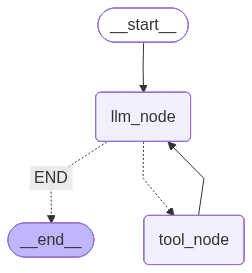

In [93]:
graph=StateGraph(schema)
graph.add_node("llm_node",llm_node)
tool_node=ToolNode(tools)
graph.add_node("tool_node",tool_node)
graph.add_edge(START,"llm_node")
graph.add_conditional_edges("llm_node",where_to_go,
     {
    "tool_node": "tool_node",
    "END": END})
graph.add_edge("tool_node","llm_node")
app=graph.compile()
app

In [108]:
for res in app.stream({"messages":[HumanMessage(content="sdfad")]},stream_mode="values"):
    print(res['messages'][-1].pretty_print())

================================ Human Message =================================

sdfad
None
================================== Ai Message ==================================

I didn't find any relevant information in my database about that topic. Can you please provide more context or rephrase your question?
None


In [ ]:
res=app.invoke({'messages':[HumanMessage(content="Unified Process")]})

In [107]:
for msg in res['messages']:
    print(msg.pretty_print())

================================ Human Message =================================

Unified Process
None
================================== Ai Message ==================================
Tool Calls:
  retrieve_documents (pkxhvkyvn)
 Call ID: pkxhvkyvn
  Args:
    query: Unified Process
None
================================= Tool Message =================================
Name: retrieve_documents

Life of a Unified Process
•
Unified Process repeats over a series of cycles each concluding with a
product release (increment) to the users
•

•
Unified Process is distinguished by being

 Use-case driven

 Architecture-centric

 Iterative and incremental

7/25/2025
4
Life of a Unified Process
•
Unified Process repeats over a series of cycles each concluding with a
product release (increment) to the users
•

7/25/2025
1
DA-IICT
IT 314: Software Engineering
Software Process Models – RUP|XP|TDD
1
RUP – Rational Unified Process
•
Life Cycle model proposed by Booch, Jacobson, and Rumbaugh
None
====